# 01 Extraction

This notebook is used to load the raw used cars dataset and perform the initial extraction and profiling steps for Phase 1.

## Objectives
- Load the dataset
- Inspect shape, columns, and data types
- Measure missing values and duplicates
- Check for obvious outliers
- Explore price distribution and key feature relationships

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('../data/raw/vehicles_raw.csv', low_memory=False)
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7310002491,https://anchorage.craigslist.org/ctd/d/wasilla...,anchorage / mat-su,https://anchorage.craigslist.org,23975.0,2015.0,mercedes-benz,cla250 4matic awd,NaN,NaN,gas,53348.0,clean,automatic,WDDSJ4GB6FN210463,NaN,NaN,NaN,NaN,https://images.craigslist.org/00X0X_jPCRxqu9cQ...,Located at Magnum Motors in Wasilla!,NaN,ak,61.573915,-149.399197,2021-04-20T12:06:12-0800
1,7305663391,https://fayar.craigslist.org/cto/d/farmington-...,fayetteville,https://fayar.craigslist.org,36500.0,1973.0,chevrolet,camaro z28,NaN,NaN,gas,22673.0,clean,manual,NaN,NaN,NaN,NaN,NaN,https://images.craigslist.org/00n0n_kal4Q5rPkh...,"1973 Camaro true Z28, 6.6L small block 400 eng...",NaN,ar,36.043600,-94.253900,2021-04-12T11:07:20-0500
2,7308470051,https://flagstaff.craigslist.org/ctd/d/flagsta...,flagstaff / sedona,https://flagstaff.craigslist.org,21495.0,2018.0,ford,mustang,good,NaN,gas,63210.0,clean,automatic,1FATP8UH1J5133108,NaN,NaN,other,silver,https://images.craigslist.org/00606_8ncYPGifS0...,Why Buy From Flagstaff Chevrolet?Welcome to Fl...,NaN,az,35.189958,-111.666438,2021-04-17T14:00:28-0700
3,7315427917,https://huntsville.craigslist.org/ctd/d/lawren...,huntsville / decatur,https://huntsville.craigslist.org,31900.0,2016.0,gmc,sierra 3500,NaN,NaN,gas,140000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,https://images.craigslist.org/00B0B_95qDdbA8el...,"16 GMC Sierra 3500, 4x4, Crew Cab, Flatbed, Du...",NaN,al,35.265997,-87.322254,2021-05-01T13:41:49-0500
4,7313689104,https://prescott.craigslist.org/ctd/d/prescott...,prescott,https://prescott.craigslist.org,39495.0,2020.0,ram,1500,like new,8 cylinders,gas,33629.0,clean,automatic,1C6RREDTXKN864758,rwd,full-size,truck,silver,https://images.craigslist.org/00c0c_ijqXiukr6Q...,"2019 Ram 1500 Quad Cab Laramie, 33,624 miles, ...",NaN,az,34.586025,-112.318347,2021-04-27T20:34:00-0700


In [3]:
df.shape, df.columns.tolist()

((15000, 26),
 ['id',
  'url',
  'region',
  'region_url',
  'price',
  'year',
  'manufacturer',
  'model',
  'condition',
  'cylinders',
  'fuel',
  'odometer',
  'title_status',
  'transmission',
  'VIN',
  'drive',
  'size',
  'type',
  'paint_color',
  'image_url',
  'description',
  'county',
  'state',
  'lat',
  'long',
  'posting_date'])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            15000 non-null  int64  
 1   url           15000 non-null  str    
 2   region        14999 non-null  str    
 3   region_url    14999 non-null  str    
 4   price         14999 non-null  float64
 5   year          14914 non-null  float64
 6   manufacturer  14340 non-null  str    
 7   model         14785 non-null  str    
 8   condition     8796 non-null   str    
 9   cylinders     8785 non-null   str    
 10  fuel          14902 non-null  str    
 11  odometer      14826 non-null  float64
 12  title_status  14737 non-null  str    
 13  transmission  14947 non-null  str    
 14  VIN           9401 non-null   str    
 15  drive         10575 non-null  str    
 16  size          3926 non-null   str    
 17  type          11683 non-null  str    
 18  paint_color   10818 non-null  str    

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_pct.round(2)
}).query('missing_count > 0')

,missing_count,missing_percent
county,15000,100.00
size,11074,73.83
cylinders,6215,41.43
condition,6204,41.36
VIN,5599,37.33
drive,4425,29.50
paint_color,4182,27.88
type,3317,22.11
manufacturer,660,4.40
title_status,263,1.75


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
if 'price' in df.columns:
    df['price'].describe()

In [8]:
numeric_cols = ['price', 'year', 'odometer']
available_numeric = [col for col in numeric_cols if col in df.columns]
df[available_numeric].describe()

,price,year,odometer
count,1.499900e+04,14914.000000,1.482600e+04
mean,9.227665e+04,2011.702494,9.812538e+04
std,8.105449e+06,9.979436,3.180244e+05
min,0.000000e+00,1901.000000,0.000000e+00
25%,7.500000e+03,2009.000000,3.115700e+04
50%,1.699000e+04,2014.000000,7.558800e+04
75%,2.907500e+04,2017.000000,1.257678e+05
max,9.876543e+08,2021.000000,1.000000e+07


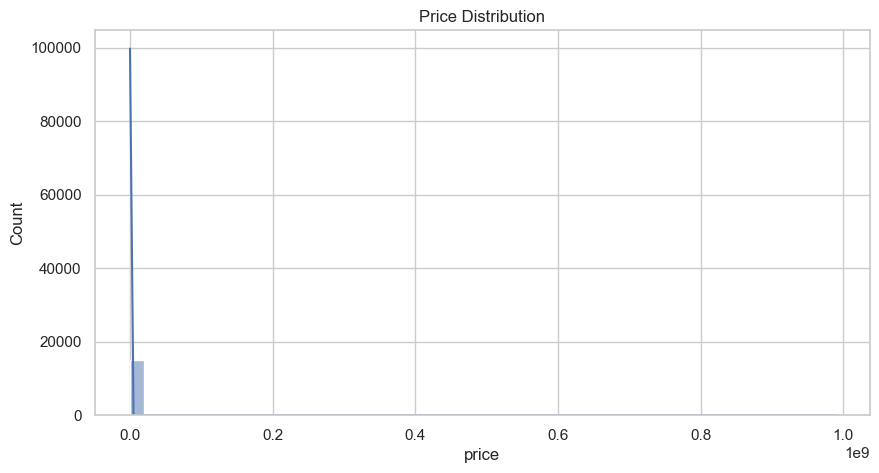

In [9]:
if 'price' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df['price'].dropna(), bins=50, kde=True)
    plt.title('Price Distribution')
    plt.show()

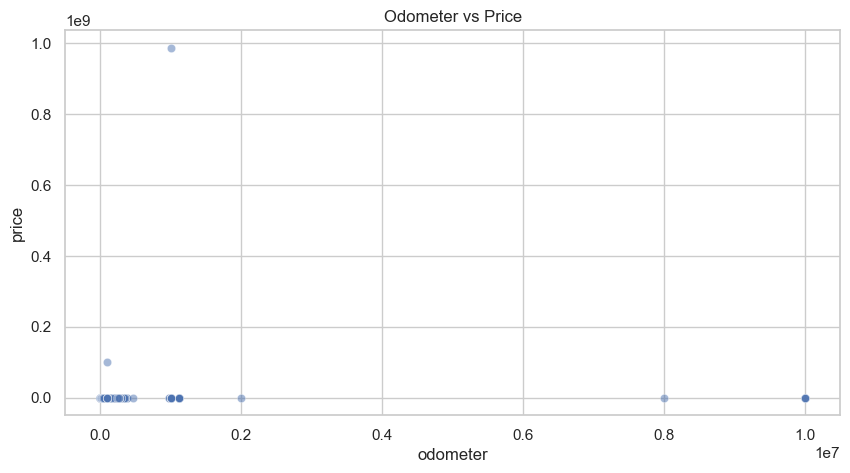

In [10]:
if {'odometer', 'price'}.issubset(df.columns):
    sample_df = df[['odometer', 'price']].dropna().sample(min(5000, df[['odometer', 'price']].dropna().shape[0]), random_state=42)
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=sample_df, x='odometer', y='price', alpha=0.5)
    plt.title('Odometer vs Price')
    plt.show()

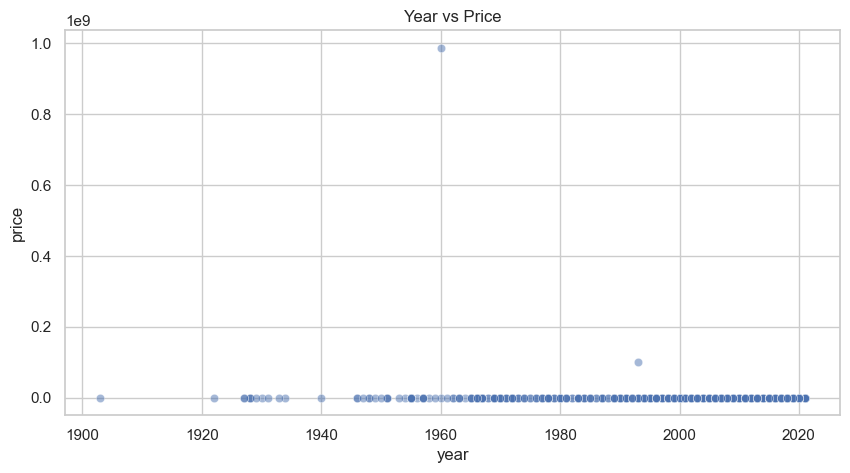

In [11]:
if {'year', 'price'}.issubset(df.columns):
    sample_df = df[['year', 'price']].dropna().sample(min(5000, df[['year', 'price']].dropna().shape[0]), random_state=42)
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=sample_df, x='year', y='price', alpha=0.5)
    plt.title('Year vs Price')
    plt.show()